In [1]:
pip install mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Importing libraries
import pandas as pd
import json
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import networkx as nx
from IPython.display import display
import ipywidgets as widgets

### Loading the dataset

In [4]:
file_path1= (r'C:\Users\Admin\Documents\data mining\IndividualAssignment2\All_Beauty_5.json.gz')
file_path2= (r'C:\Users\Admin\Documents\data mining\IndividualAssignment2\meta_All_Beauty.json.gz')

# Loading review dataset
reviews_df= pd.read_json(file_path1, lines= True)  #each line in JSON file is its own object so read and parese them line by line, then combine into DF

# Loading metadata dataset
meta_df= pd.read_json(file_path2, lines= True)

### Basic information about the dataset

In [5]:
reviews_df.head()

,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image
0,5,True,"09 1, 2016",A3CIUOJXQ5VDQ2,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Shelly F,As advertised. Reasonably priced,Five Stars,1472688000,NaN,NaN
1,5,True,"11 14, 2013",A3H7T87S984REU,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",houserules18,Like the oder and the feel when I put it on my...,Good for the face,1384387200,NaN,NaN
2,1,True,"08 18, 2013",A3J034YH7UG4KT,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Adam,I bought this to smell nice after I shave. Wh...,Smells awful,1376784000,NaN,NaN
3,5,False,"05 3, 2011",A2UEO5XR3598GI,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Rich K,HEY!! I am an Aqua Velva Man and absolutely lo...,Truth is There IS Nothing Like an AQUA VELVA MAN.,1304380800,25,NaN
4,5,True,"05 6, 2011",A3SFRT223XXWF7,B00006L9LC,{'Size:': ' 200ml/6.7oz'},C. C. Christian,If you ever want to feel pampered by a shampoo...,Bvlgari Shampoo,1304640000,3,NaN


In [6]:
meta_df.head()

,category,tech1,description,fit,title,also_buy,tech2,brand,feature,rank,also_view,details,main_cat,similar_item,date,price,asin,imageURL,imageURLHighRes
0,[],,[Loud 'N Clear Personal Sound Amplifier allows...,,Loud 'N Clear&trade; Personal Sound Amplifier,[],,idea village,[],"2,938,573 in Beauty & Personal Care (",[],{'ASIN: ': '6546546450'},All Beauty,,,,6546546450,[],[]
1,[],,[No7 Lift & Luminate Triple Action Serum 50ml ...,,No7 Lift &amp; Luminate Triple Action Serum 50...,"[B01E7LCSL6, B008X5RVME]",,,[],"872,854 in Beauty & Personal Care (",[],"{'Shipping Weight:': '0.3 ounces (', 'ASIN: ':...",All Beauty,"class=""a-bordered a-horizontal-stripes a-spa...",,$44.99,7178680776,[],[]
2,[],,[No7 Stay Perfect Foundation now stays perfect...,,No7 Stay Perfect Foundation Cool Vanilla by No7,[],,No7,[],"956,696 in Beauty & Personal Care (","[B01B8BR0O8, B01B8BR0NO, B014MHXXM8]","{'Shipping Weight:': '3.5 ounces (', 'ASIN: ':...",All Beauty,,,$28.76,7250468162,[],[]
3,[],,[],,Wella Koleston Perfect Hair Colour 44/44 Mediu...,[B0041PBXX8],,,[],"1,870,258 in Beauty & Personal Care (",[],"{' Item Weight: ': '1.76 ounces', 'Sh...",All Beauty,,,,7367905066,[https://images-na.ssl-images-amazon.com/image...,[https://images-na.ssl-images-amazon.com/image...
4,[],,[Lacto Calamine Skin Balance Daily Nourishing ...,,Lacto Calamine Skin Balance Oil control 120 ml...,[],,Pirmal Healthcare,[],"67,701 in Beauty & Personal Care (","[3254895630, B007VL1D9S, B00EH9A0RI, B0773MBG4...","{'Shipping Weight:': '12 ounces (', 'ASIN: ': ...",All Beauty,,,$12.15,7414204790,[https://images-na.ssl-images-amazon.com/image...,[https://images-na.ssl-images-amazon.com/image...


In [7]:
# checking the available fields in both dataset
meta_df.columns

Index(['category', 'tech1', 'description', 'fit', 'title', 'also_buy', 'tech2',
       'brand', 'feature', 'rank', 'also_view', 'details', 'main_cat',
       'similar_item', 'date', 'price', 'asin', 'imageURL', 'imageURLHighRes'],
      dtype='object')

In [8]:
reviews_df.columns

Index(['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style',
       'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote',
       'image'],
      dtype='object')

In [9]:
print("Number of reviews:", len(reviews_df))
print("\nNumber of unique reviewers:", reviews_df['reviewerID'].nunique())
print("\nNumber of unique products:", meta_df['title'].nunique())

Number of reviews: 5269

Number of unique reviewers: 991

Number of unique products: 32300


## **Data preprocessing**

### a. Data Cleaning

#### **Cleaning Reviews data**

In [10]:
# checking structure 
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5269 entries, 0 to 5268
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   overall         5269 non-null   int64 
 1   verified        5269 non-null   bool  
 2   reviewTime      5269 non-null   object
 3   reviewerID      5269 non-null   object
 4   asin            5269 non-null   object
 5   style           4624 non-null   object
 6   reviewerName    5269 non-null   object
 7   reviewText      5264 non-null   object
 8   summary         5264 non-null   object
 9   unixReviewTime  5269 non-null   int64 
 10  vote            552 non-null    object
 11  image           98 non-null     object
dtypes: bool(1), int64(2), object(9)
memory usage: 458.1+ KB


In [11]:
print("\nMissing values per columns of Review Dataset:")
print(reviews_df.isnull().sum())


Missing values per columns of Review Dataset:
overall              0
verified             0
reviewTime           0
reviewerID           0
asin                 0
style              645
reviewerName         0
reviewText           5
summary              5
unixReviewTime       0
vote              4717
image             5171
dtype: int64


In [12]:
print("\nMissing values per columns of Metadata Dataset:")
print(meta_df.isnull().sum())


Missing values per columns of Metadata Dataset:
category           0
tech1              0
description        0
fit                0
title              0
also_buy           0
tech2              0
brand              0
feature            0
rank               0
also_view          0
details            0
main_cat           0
similar_item       0
date               0
price              0
asin               0
imageURL           0
imageURLHighRes    0
dtype: int64


#### **b. Data Integration**
Merging metadata `title` into reviews using `ASIN` to get product names like `(transcation -> item)`

In [13]:
merged_df= pd.merge(reviews_df, meta_df[['asin', 'title']], on='asin', how='inner')

merged_df.head()

,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image,title
0,5,True,"09 1, 2016",A3CIUOJXQ5VDQ2,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Shelly F,As advertised. Reasonably priced,Five Stars,1472688000,NaN,NaN,"Aqua Velva After Shave, Classic Ice Blue, 7 Ounce"
1,5,True,"09 1, 2016",A3CIUOJXQ5VDQ2,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Shelly F,As advertised. Reasonably priced,Five Stars,1472688000,NaN,NaN,"Aqua Velva After Shave, Classic Ice Blue, 7 Ounce"
2,5,True,"11 14, 2013",A3H7T87S984REU,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",houserules18,Like the oder and the feel when I put it on my...,Good for the face,1384387200,NaN,NaN,"Aqua Velva After Shave, Classic Ice Blue, 7 Ounce"
3,5,True,"11 14, 2013",A3H7T87S984REU,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",houserules18,Like the oder and the feel when I put it on my...,Good for the face,1384387200,NaN,NaN,"Aqua Velva After Shave, Classic Ice Blue, 7 Ounce"
4,1,True,"08 18, 2013",A3J034YH7UG4KT,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Adam,I bought this to smell nice after I shave. Wh...,Smells awful,1376784000,NaN,NaN,"Aqua Velva After Shave, Classic Ice Blue, 7 Ounce"


#### **c. Data Transformation**
- `groupby()` + `list` : puts all items reviewed by the same user into a list called **"basket"**

In [14]:
basket_df= merged_df.groupby('reviewerID')['title'].apply(list).reset_index()

# renaming the column
basket_df.columns= ['reviewerID', 'basket']
basket_df.head()

,reviewerID,basket
0,A105A034ZG9EHO,[Yardley By Yardley Of London Unisexs Lay It O...
1,A10JB7YPWZGRF4,[Yardley By Yardley Of London Unisexs Lay It O...
2,A10M2MLE2R0L6K,"[essie nail polish, cuticle care, primers and ..."
3,A10P0NAKKRYKTZ,[Yardley By Yardley Of London Unisexs Lay It O...
4,A10ZJZNO4DAVB,[Citre Shine Moisture Burst Shampoo - 16 fl oz...


#### **d. Data reduction**
- removing rare items, to reduce noise as:
  - Apriori is slow with large.
  - rare items don't add value for rule generation

In [15]:
# using explode() + value_counts() for counting item frequencies
item_freq = basket_df.explode('basket')['basket'].value_counts()  # explode('basket') turns each list of item into seperate rows

# creating set of item that appear atleast twice
frequent_items = set(item_freq[item_freq>=2].index)

# keeping only frequent items in each basket
basket_df['basket'] = basket_df['basket'].apply(lambda items: [item for item in items if item in frequent_items])  # apply(lamba..) filters each user's basket

basket_df= basket_df[basket_df['basket'].map(len)>0]

## **One-Hot encoding**
To apply Apriori, data should be in binary matrix format where:

- Baskets (transactions by user)= rows
- Items (products) = columns
- if item is in basket 1, else 0


In [16]:
# converting 'basket' into a list of lists
transactions = basket_df['basket'].tolist()
print (transactions)

[['Yardley By Yardley Of London Unisexs Lay It On Thick Hand &amp; Foot Cream 5.3 Oz', 'Fruits &amp; Passion Blue Refreshing Shower Gel - 6.7 fl. oz.', 'Bonne Bell Smackers Bath and Body Starburst Collection', 'Bath &amp; Body Works Ile De Tahiti Moana Coconut Vanille Moana Body Wash with Tamanoi 8.5 oz', 'Bath &amp; Body Works Ile De Tahiti Moana Coconut Vanille Moana Body Wash with Tamanoi 8.5 oz'], ['Yardley By Yardley Of London Unisexs Lay It On Thick Hand &amp; Foot Cream 5.3 Oz', 'Fruits &amp; Passion Blue Refreshing Shower Gel - 6.7 fl. oz.', 'Bonne Bell Smackers Bath and Body Starburst Collection', 'Bath &amp; Body Works Ile De Tahiti Moana Coconut Vanille Moana Body Wash with Tamanoi 8.5 oz', 'Bath &amp; Body Works Ile De Tahiti Moana Coconut Vanille Moana Body Wash with Tamanoi 8.5 oz'], ['essie nail polish, cuticle care, primers and finishers', 'essie nail polish, cuticle care, primers and finishers', 'Pre de Provence Maison French Dried Lavender Blossoms for Fragrance', 'Pr

one user's reviewed products = each list in a transaction

In [17]:
# using TransactionEncoder
trans = TransactionEncoder()

trans_array= trans.fit(transactions).transform(transactions)   # trans.fit(transactions) :learns all product titles
                                                               # transform() : creates binary matrix

#converting matrix into dataframe for Apriori
encoded_df= pd.DataFrame(trans_array, columns= trans.columns_) 

In [18]:
encoded_df.head()

,Colgate Fluoride Toothpaste Strawberry Smash Liquid Gel 4.60 oz (Pack of 6),(Pack of 3) L.A. Colors Mineral Pressed Powder #Mp303 &quot;Creamy Natural&quot;,"AGELESS: UltraMAX Gold Capsules, 90 count",AMERICAN CREW by American Crew: CLASSIC BODY WASH 15.2 OZ,"AXE Shower Tool, Detailer 1 ea, Pack of 4","Aqua Velva After Shave, Classic Ice Blue, 3.5 Ounce","Aqua Velva After Shave, Classic Ice Blue, 7 Ounce","Aquaphor Healing Ointment,Advanced Therapy Skin Protectant 14 Ounce ( Pack May Vary )","Astra Platinum Double Edge Safety Razor Blades ,100 Blades (20 x 5)","Avalon Grapefruit and Geranium Smoothing Shampoo, 11 Ounce",...,Urban Spa Natural Bamboo and Jute Bath Mitt,Victoria's Secret Dream Angels HEAVENLY Angel Wash 7.6 oz,Waterpik Ultra Water Flosser,"Whish Coconut Shaving Cream - Smooth, All Natural Shave Cream for Men &amp; Women, Leaves Skin so Soft, Shea Butter and Coconut Oil, Natural and Organic Skin Care - 5 oz. pump","Williams Lectric Shave, 7 Ounce",WiseWays Herbals Witch Hazel Salve 1 oz.,Yardley By Yardley Of London Unisexs Lay It On Thick Hand &amp; Foot Cream 5.3 Oz,"ZUM Zum Bar Anise Lavender, 3 Ounce",essie Gel Couture Nail Polish,"essie nail polish, cuticle care, primers and finishers"
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## **Applying Apriori**

- finding frequent itemsets
- identifying products often reviewed together

In [19]:
frequent_itemsets = apriori(encoded_df, 
                            min_support=0.01, # min_support= 0.01 means itemsets appearing in at least 1% of transcations
                            use_colnames=True, # this shows actual product names
                            verbose=1) # show progress during processing
frequent_itemsets.head()

Processing 18 combinations | Sampling itemset size 65


,support,itemsets
0,0.013118,( Colgate Fluoride Toothpaste Strawberry Smash...
1,0.493441,(Avalon Grapefruit and Geranium Smoothing Sham...
2,0.880928,(Bath &amp; Body Works Ile De Tahiti Moana Coc...
3,0.857719,(Bonne Bell Smackers Bath and Body Starburst C...
4,0.012109,(Caress Body Wash - Sheer Twilight - 18 oz - 2...


## **Generating Association rules**

In [20]:
rules = association_rules(frequent_itemsets,
                          metric= 'confidence', # probability of B given A
                          min_threshold= 0.5) # keeps rules with at least 50% confidence

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

,antecedents,consequents,support,confidence,lift
0,( Colgate Fluoride Toothpaste Strawberry Smash...,(Colgate Kids Maximum Cavity Protection Pump T...,0.013118,1.000000,76.230769
1,(Colgate Kids Maximum Cavity Protection Pump T...,( Colgate Fluoride Toothpaste Strawberry Smash...,0.013118,1.000000,76.230769
2,(Bath &amp; Body Works Ile De Tahiti Moana Coc...,(Avalon Grapefruit and Geranium Smoothing Sham...,0.493441,0.560137,1.135166
3,(Avalon Grapefruit and Geranium Smoothing Sham...,(Bath &amp; Body Works Ile De Tahiti Moana Coc...,0.493441,1.000000,1.135166
4,(Bonne Bell Smackers Bath and Body Starburst C...,(Avalon Grapefruit and Geranium Smoothing Sham...,0.486377,0.567059,1.149193


In [21]:
# to find strongest and most surprising rules: Sorting rules by lift
rules.sort_values('lift', ascending= False). head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,( Colgate Fluoride Toothpaste Strawberry Smash...,(Colgate Kids Maximum Cavity Protection Pump T...,0.013118,0.013118,0.013118,1.000000,76.230769,1.0,0.012946,inf,1.0,1.000000,1.000000,1.000000
1,(Colgate Kids Maximum Cavity Protection Pump T...,( Colgate Fluoride Toothpaste Strawberry Smash...,0.013118,0.013118,0.013118,1.000000,76.230769,1.0,0.012946,inf,1.0,1.000000,1.000000,1.000000
33,(Lectric Shave Pre-Shave Original 3 oz),"(Williams Lectric Shave, 7 Ounce)",0.017154,0.017154,0.017154,1.000000,58.294118,1.0,0.016860,inf,1.0,1.000000,1.000000,1.000000
34,"(Williams Lectric Shave, 7 Ounce)",(Lectric Shave Pre-Shave Original 3 oz),0.017154,0.017154,0.017154,1.000000,58.294118,1.0,0.016860,inf,1.0,1.000000,1.000000,1.000000
140,(Pre de Provence Maison French Dried Lavender ...,(Pre De Provence Maison French Lavender Bath &...,0.033300,0.026236,0.026236,0.787879,30.030303,1.0,0.025362,4.590601,1.0,0.787879,0.782164,0.893939


## **Filtering and analysing Top Rules**

- highlighting most useful and actionable rules
- focus on lift, confidence and support

In [22]:
# filtering strong rules
strong_rules= rules[(rules['lift']>1) & (rules['confidence']>=0.6)]

# strongest associations by sorting lift
strong_rules= strong_rules.sort_values(by='lift', ascending= False)

strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift
0,( Colgate Fluoride Toothpaste Strawberry Smash...,(Colgate Kids Maximum Cavity Protection Pump T...,0.013118,1.000000,76.230769
1,(Colgate Kids Maximum Cavity Protection Pump T...,( Colgate Fluoride Toothpaste Strawberry Smash...,0.013118,1.000000,76.230769
33,(Lectric Shave Pre-Shave Original 3 oz),"(Williams Lectric Shave, 7 Ounce)",0.017154,1.000000,58.294118
34,"(Williams Lectric Shave, 7 Ounce)",(Lectric Shave Pre-Shave Original 3 oz),0.017154,1.000000,58.294118
140,(Pre de Provence Maison French Dried Lavender ...,(Pre De Provence Maison French Lavender Bath &...,0.026236,0.787879,30.030303
141,(Pre De Provence Maison French Lavender Bath &...,(Pre de Provence Maison French Dried Lavender ...,0.026236,0.787879,30.030303
36,(Pre De Provence Maison French Lavender Bath &...,(Pre de Provence Maison French Dried Lavender ...,0.033300,1.000000,30.030303
37,(Pre de Provence Maison French Dried Lavender ...,(Pre De Provence Maison French Lavender Bath &...,0.033300,1.000000,30.030303
144,(Pre De Provence Maison French Lavender Bath &...,(Pre de Provence Maison French Dried Lavender ...,0.019173,1.000000,30.030303
145,(Pre de Provence Maison French Dried Lavender ...,(Pre De Provence Maison French Lavender Bath &...,0.019173,1.000000,30.030303


## **Visualizing rules**

### a. Bar plot of Top 10 rules by lift

In [23]:
# top 10 rules by lift from strong rules
ten = strong_rules.sort_values(by='lift', ascending=False).head(10)

#convert frozensets to strings for readability
ten['rule'] = ten['antecedents'].apply(lambda x: ', '.join(list(x))) + ' → ' + ten['consequents'].apply(lambda x: ', '.join(list(x)))

C:\Users\Admin\AppData\Local\Temp\ipykernel_3036\1688299589.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ten['lift'], y=ten['rule_wrapped'], palette='viridis')


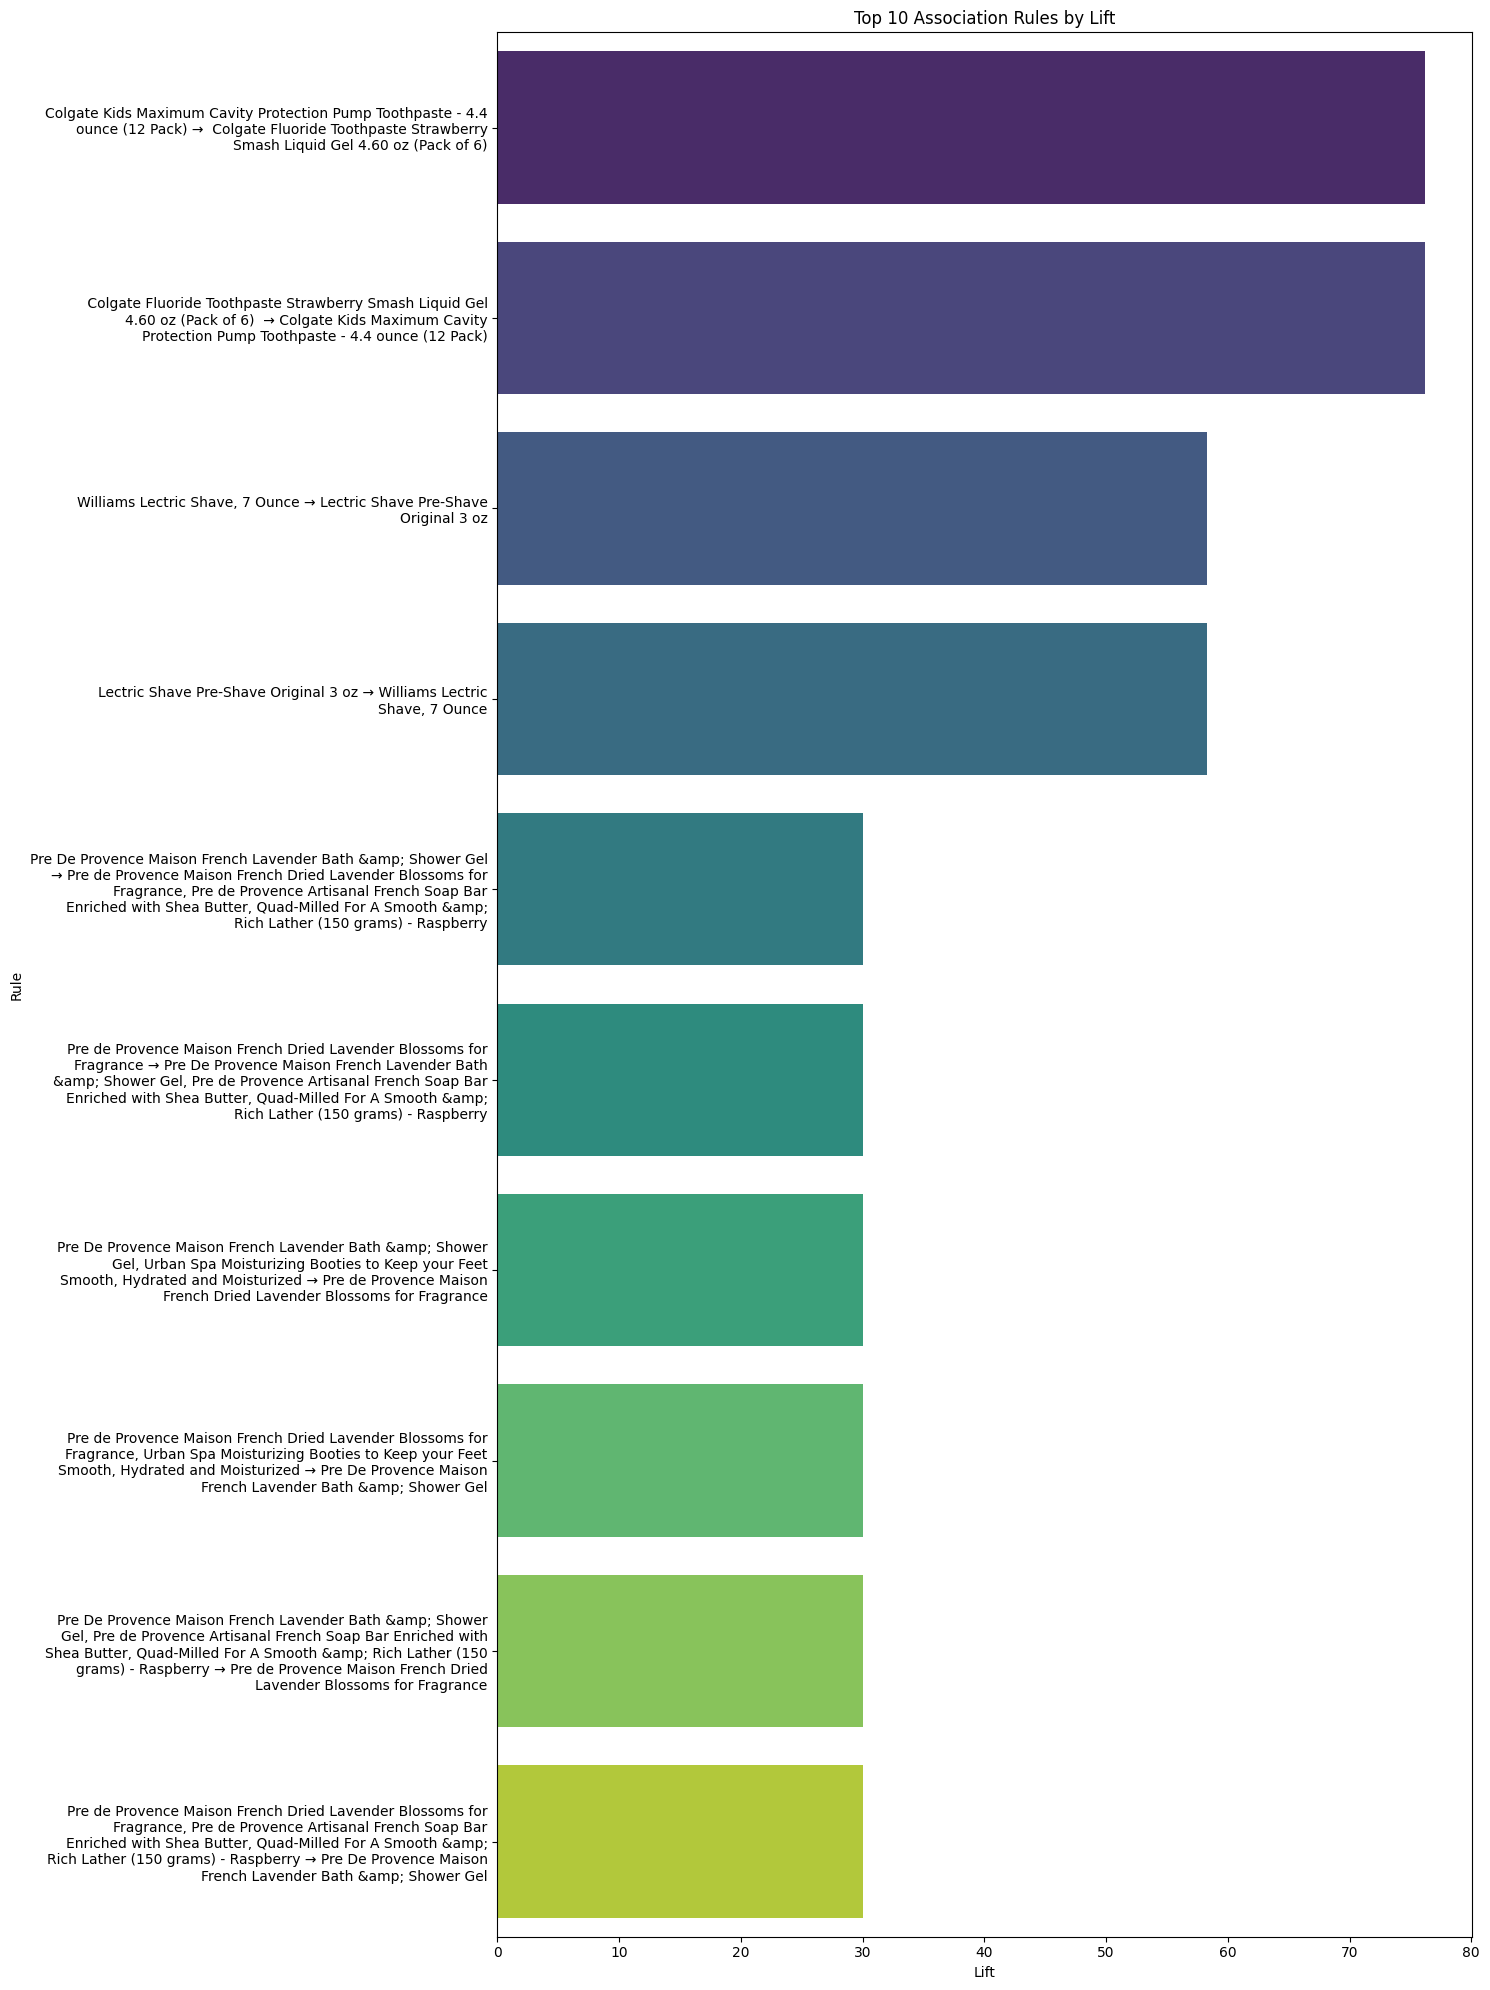

In [24]:
#wrapp each rule string into multiple lines as title too long
def wrap_text(text, width=50):
    return '\n'.join(textwrap.wrap(text, width))

# # convverting forzensets (cannot be changed once it is created) to string for plottig
ten['rule_wrapped'] = ten['rule'].apply(lambda x: wrap_text(x, width=60))

# ploting with wrapped labels
plt.figure(figsize=(15, 20))
sns.barplot(x=ten['lift'], y=ten['rule_wrapped'], palette='viridis')
plt.title('Top 10 Association Rules by Lift')
plt.xlabel('Lift')
plt.ylabel('Rule')
plt.tight_layout()
plt.show()

### b. Network graph to visualize Association rules

In [25]:
# creating a directed graph
graph = nx.DiGraph()

# top 10 strongest rules
top_rules= strong_rules.head(10)

# converting frozenset string before adding nodes and edges
for _, row in top_rules.iterrows():
    antecedent= ','.join(list(row['antecedents']))
    consequent= ','.join(list(row['consequents']))
    lift= round(row['lift'], 2)

    # adding edge with lift as weight
    graph.add_edge(antecedent, consequent, weight= lift, label= f"lift={lift}")

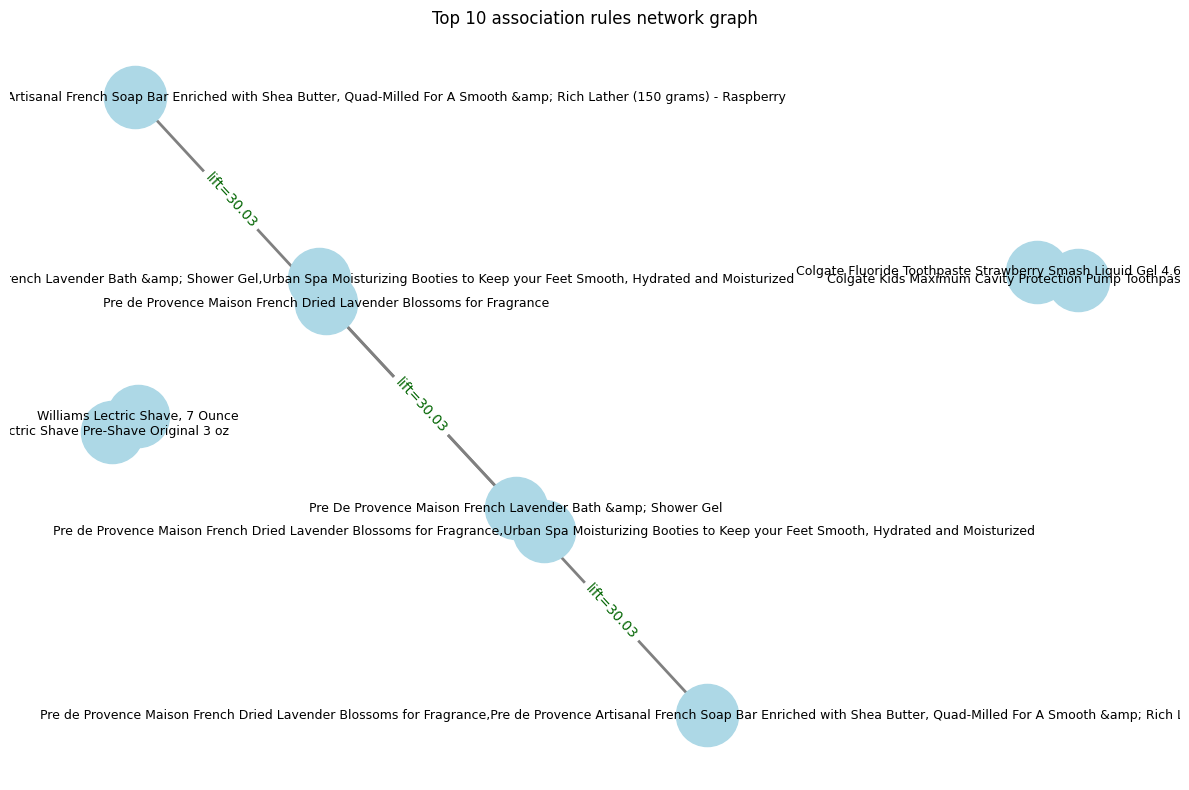

In [26]:
# drawing graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(graph, k=0.5, seed=42)

# drawing nodes
nx.draw_networkx_nodes(graph, pos, node_size= 2000, node_color='lightblue')
nx.draw_networkx_edges(graph, pos, width= 2, edge_color='gray', arrows= True)

nx.draw_networkx_labels(graph, pos, font_size= 9, font_color ='black')

# adding edge labels/ lift values
edge_labels= nx.get_edge_attributes(graph, 'label')
nx.draw_networkx_edge_labels(graph, pos, edge_labels= edge_labels, font_color='darkgreen')

plt.title("Top 10 association rules network graph")
plt.axis('off')
plt.tight_layout()
plt.show()

### c. Item frequency distribution plot

<Axes: title={'center': 'Top 15 Most Purchased Products'}>

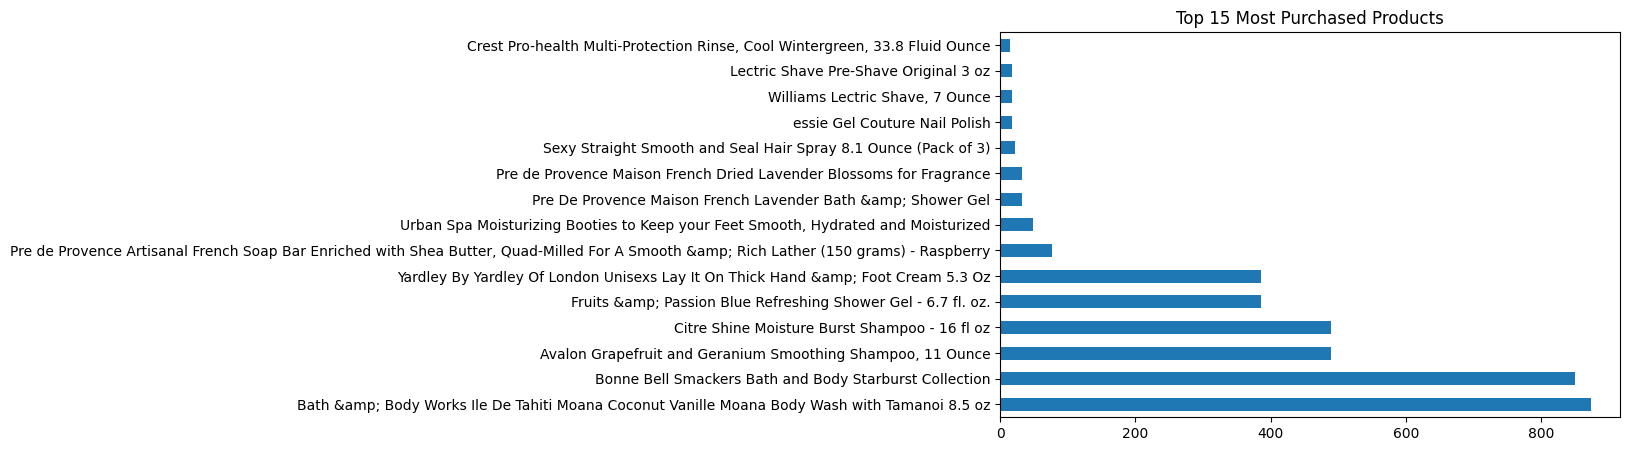

In [27]:
item_counts = encoded_df.sum().sort_values(ascending=False).head(15)
item_counts.plot(kind='barh', title='Top 15 Most Purchased Products', figsize=(8, 5))

## **Product specific Recommendation**

In [28]:
# converting frozenset to string for filtering
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ','.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ','.join(list(x)))

In [29]:
# choosing target product to analyze
target_product= "Shampoo"

In [30]:
# filtering the rules where the product appears in the antecedent
product_rules= rules[rules['antecedents_str'].str.contains(target_product, case= False)]

In [31]:
# sorting and viewing top rules by lift
top_recommendations= product_rules.sort_values(by='lift', ascending= False).head(5)

# Display selected columns
top_recommendations[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]

,antecedents_str,consequents_str,support,confidence,lift
312,Theorie Argan Oil Ultimate Reform Shampoo &amp...,"Citre Shine Moisture Burst Shampoo - 16 fl oz,...",0.010091,1.0,2.060291
227,Theorie Argan Oil Ultimate Reform Shampoo &amp...,"Citre Shine Moisture Burst Shampoo - 16 fl oz,...",0.010091,1.0,2.060291
311,Theorie Argan Oil Ultimate Reform Shampoo &amp...,"Citre Shine Moisture Burst Shampoo - 16 fl oz,...",0.010091,1.0,2.060291
78,Theorie Argan Oil Ultimate Reform Shampoo &amp...,Bonne Bell Smackers Bath and Body Starburst Co...,0.010091,1.0,2.056017
272,Bath &amp; Body Works Ile De Tahiti Moana Coco...,"Citre Shine Moisture Burst Shampoo - 16 fl oz,...",0.012109,1.0,2.056017


In [32]:
for _, row in top_recommendations.iterrows():
    print(f"If a customer buys *{row['antecedents_str']}*, recommend *{row['consequents_str']}* (Lift={row['lift']:.2f})")

If a customer buys *Theorie Argan Oil Ultimate Reform Shampoo &amp; Conditioner 27 Fl Oz Each*, recommend *Citre Shine Moisture Burst Shampoo - 16 fl oz,Bath &amp; Body Works Ile De Tahiti Moana Coconut Vanille Moana Body Wash with Tamanoi 8.5 oz,Bonne Bell Smackers Bath and Body Starburst Collection,Avalon Grapefruit and Geranium Smoothing Shampoo, 11 Ounce* (Lift=2.06)
If a customer buys *Theorie Argan Oil Ultimate Reform Shampoo &amp; Conditioner 27 Fl Oz Each*, recommend *Citre Shine Moisture Burst Shampoo - 16 fl oz,Bonne Bell Smackers Bath and Body Starburst Collection,Avalon Grapefruit and Geranium Smoothing Shampoo, 11 Ounce* (Lift=2.06)
If a customer buys *Theorie Argan Oil Ultimate Reform Shampoo &amp; Conditioner 27 Fl Oz Each,Bath &amp; Body Works Ile De Tahiti Moana Coconut Vanille Moana Body Wash with Tamanoi 8.5 oz*, recommend *Citre Shine Moisture Burst Shampoo - 16 fl oz,Bonne Bell Smackers Bath and Body Starburst Collection,Avalon Grapefruit and Geranium Smoothing Sha

In [33]:
# To understand what products often lead to buying the target product, keeping product in Consequent
consequent_rules = rules[rules['consequents_str'].str.contains(target_product, case=False)]
consequent_top = consequent_rules.sort_values(by='lift', ascending=False).head(5)
print("\nProducts that lead to buying", target_product)
display(consequent_top[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']])


Products that lead to buying Shampoo


,antecedents_str,consequents_str,support,confidence,lift
312,Theorie Argan Oil Ultimate Reform Shampoo &amp...,"Citre Shine Moisture Burst Shampoo - 16 fl oz,...",0.010091,1.0,2.060291
220,Sexy Straight Smooth and Seal Hair Spray 8.1 O...,"Citre Shine Moisture Burst Shampoo - 16 fl oz,...",0.022200,1.0,2.060291
227,Theorie Argan Oil Ultimate Reform Shampoo &amp...,"Citre Shine Moisture Burst Shampoo - 16 fl oz,...",0.010091,1.0,2.060291
311,Theorie Argan Oil Ultimate Reform Shampoo &amp...,"Citre Shine Moisture Burst Shampoo - 16 fl oz,...",0.010091,1.0,2.060291
297,Sexy Straight Smooth and Seal Hair Spray 8.1 O...,"Citre Shine Moisture Burst Shampoo - 16 fl oz,...",0.022200,1.0,2.060291


In [34]:
# summarizing all recommendations for the given product in one view
grouped = product_rules.groupby('antecedents_str')['consequents_str'].apply(list).reset_index()
display(grouped)

,antecedents_str,consequents_str
0,Avalon Grapefruit and Geranium Smoothing Shamp...,[Bath &amp; Body Works Ile De Tahiti Moana Coc...
1,Avalon Grapefruit and Geranium Smoothing Shamp...,[Bath &amp; Body Works Ile De Tahiti Moana Coc...
2,Bath &amp; Body Works Ile De Tahiti Moana Coco...,[Bonne Bell Smackers Bath and Body Starburst C...
3,Bath &amp; Body Works Ile De Tahiti Moana Coco...,[Bonne Bell Smackers Bath and Body Starburst C...
4,Bath &amp; Body Works Ile De Tahiti Moana Coco...,[Citre Shine Moisture Burst Shampoo - 16 fl oz]
5,Bath &amp; Body Works Ile De Tahiti Moana Coco...,[Citre Shine Moisture Burst Shampoo - 16 fl oz]
6,Bath &amp; Body Works Ile De Tahiti Moana Coco...,[Avalon Grapefruit and Geranium Smoothing Sham...
7,Bath &amp; Body Works Ile De Tahiti Moana Coco...,[Bonne Bell Smackers Bath and Body Starburst C...
8,Bath &amp; Body Works Ile De Tahiti Moana Coco...,[Bonne Bell Smackers Bath and Body Starburst C...
9,Bonne Bell Smackers Bath and Body Starburst Co...,[Bath &amp; Body Works Ile De Tahiti Moana Coc...


In [35]:
# To make it resuable for any target product, making a function
def recommend_for_product(rules_df, product_name, top_n=5):
    rules_df['antecedents_str'] = rules_df['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_df['consequents_str'] = rules_df['consequents'].apply(lambda x: ', '.join(list(x)))
    filtered = rules_df[rules_df['antecedents_str'].str.contains(product_name, case=False)]
    return filtered.sort_values(by='lift', ascending=False).head(top_n)[
        ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
    ]

recommend_for_product(rules, "Toothpaste")

,antecedents_str,consequents_str,support,confidence,lift
0,Colgate Fluoride Toothpaste Strawberry Smash ...,Colgate Kids Maximum Cavity Protection Pump To...,0.013118,1.0,76.230769
1,Colgate Kids Maximum Cavity Protection Pump To...,Colgate Fluoride Toothpaste Strawberry Smash ...,0.013118,1.0,76.230769


## **Interactive Dropdown**

#### Adding a text imput for product search:

In [36]:
product_input= widgets.Text(
    value= 'Shampoo',
    placeholder= 'Enter product keyword..',
    description ='Product',
    layout= widgets.Layout(width='50%')
)

#### Creating a function to filter and display recommendation
- filters rules with product in antecedents_str
- sorts by lift
- display top rules

In [42]:
def enhanced_recommendations(product_name):
    rules['antecedents_str']= rules['antecedents'].apply(lambda x: ','.join(list(x)))
    rules['consequents_str']= rules['consequents'].apply(lambda x: ','.join(list(x)))

    # filtering rules where product appears in antecedents
    product_rules= rules[rules['antecedents_str'].str.contains(product_name, case= False)]

    # sort by lift and get top 5
    top_rules= product_rules.sort_values(by= 'lift', ascending= False).head(5)

    display(top_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']])

    # recommendations
    if top_rules.empty:
        print(f"No recommendations found for '{product_name}'. Try another keyword.")
    else:
        print(f"\nProduct-specific insights for '{product_name}':")
        for _, row in top_rules.iterrows():
            print(f"If a customer reviews **{row['antecedents_str']}**, "
                  f"Suggest **{row['consequents_str']}**"
                  f"(Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f})")

In [43]:
widgets.interact(enhanced_recommendations, product_name=product_input)

interactive(children=(Text(value='oil', description='Product', layout=Layout(width='50%'), placeholder='Enter …

<function __main__.enhanced_recommendations(product_name)>